In [13]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict

In [14]:
# import dataset for dimensionality reduction
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')

# split the dataset into features and target variable
X = df.drop('sii', axis=1)
y = df['sii']
# convert X and y to numpy arrays
X = X.values # features
y = y.values # target variable

# Feature Selection

In [15]:
from sklearn.feature_selection import SelectKBest 

# select the 10 best features based on the ANOVA F-value between label/feature for classification tasks

sel = SelectKBest(k=10)
X_sel = sel.fit_transform(X, y)

X_sel.shape

(8460, 10)

In [16]:
# see which features were selected
mask = sel.get_support() # list of booleans
new_features = [] # the list of your K best features
for bool, feature in zip(mask, df.columns):
    if bool:
        new_features.append(feature)
print(new_features)


['Basic_Demos-Age', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'FGC-FGC_CU', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'BIA-BIA_Fat', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday']


## Scaling

In [18]:
# scaling the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Feature Projection

## 1. Random Subspace Projection

In [19]:
from sklearn import random_projection

# since it's random, we can have different results each time we run it. 
# Therefore, we select a random state to have the same results each time 
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=42)
X_rsp = rsp.fit_transform(X)



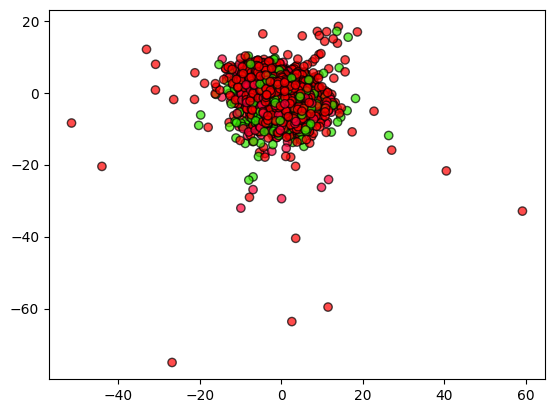

In [20]:
plt.scatter(X_rsp[:, 0], X_rsp[:, 1], c=y, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

## 2. Principal Component Analysis

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

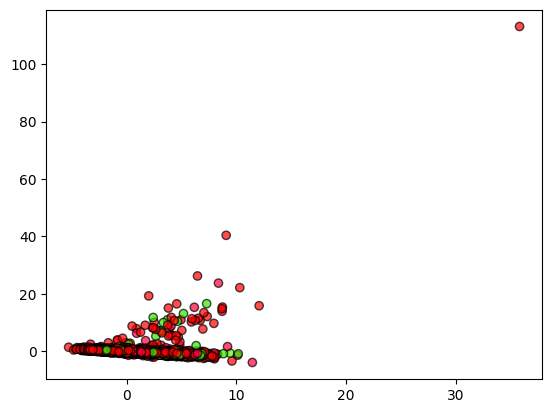

In [22]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

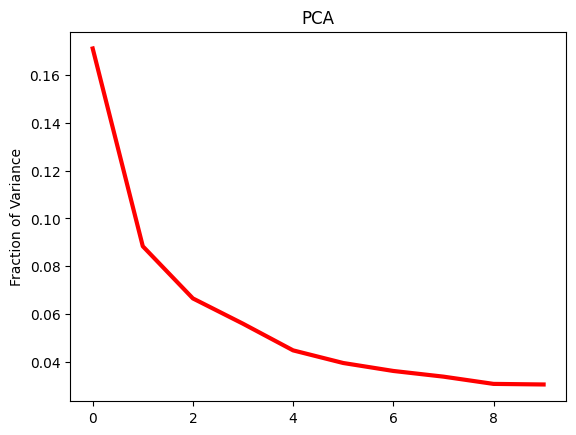

In [23]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

## 3. Multi-Dimensional Scaling

### MDS (classic)

In [ ]:
from sklearn.manifold import MDS 

mds = MDS(n_components=2) #, normalized_stress='auto') # shoudl run as sammon mapping
X_mds = mds.fit_transform(X)
X_mds.shape

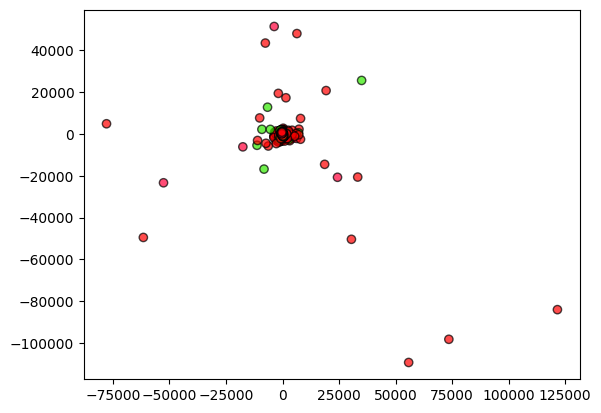

In [ ]:
plt.scatter(X_mds[:, 0], X_mds[:, 1], c=y, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

## Sammon Mapping

In [ ]:
from sammon.sammon import sammon

X_sammon, stress = sammon(X, n = 2)
X_sammon.shape

In [ ]:
plt.scatter(X_sammon[:, 0], X_sammon[:, 1], c=y, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

### IsoMap

In [ ]:
from sklearn.manifold import Isomap

iso = Isomap(n_components=2)
X_iso = iso.fit_transform(X)

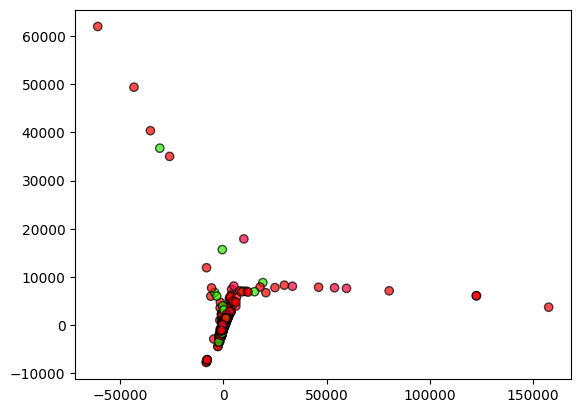

In [ ]:
plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

### t-SNE

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)

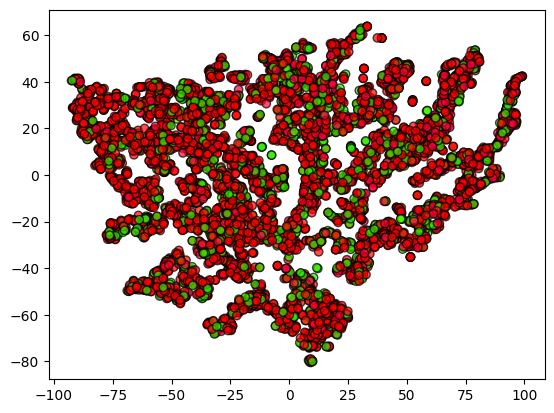

In [ ]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()